---
## 1. Imports

In [3]:
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Sandeep\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
!C:\Users\Sandeep\AppData\Local\Programs\Python\Python313\python.exe -m pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import itertools
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import pickle

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEV_LABELS  = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
SEV_COLORS  = {1: '#d32f2f', 2: '#ff9800', 3: '#2196F3'}
MODEL_COLORS = ['#9C27B0', '#2196F3', '#FF9800', '#4CAF50']

print('All libraries loaded.')

All libraries loaded.


---
## 2. Load & Merge Datasets

In [ ]:
acc = pd.read_csv('AccidentsBig.csv',  low_memory=False)
veh = pd.read_csv('VehiclesBig.csv',   low_memory=False)
cas = pd.read_csv('CasualtiesBig.csv', low_memory=False)

print(f'Accidents:  {acc.shape}  |  Vehicles: {veh.shape}  |  Casualties: {cas.shape}')

# Aggregate vehicles & casualties per accident
veh_agg = veh.groupby('Accident_Index').agg(
    num_vehicles   = ('Vehicle_Reference', 'count'),
    Age_of_Vehicle = ('Age_of_Vehicle',    'mean'),
    Age_of_Driver  = ('Age_of_Driver',     'mean'),
    Vehicle_Type   = ('Vehicle_Type',      lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    Vehicle_Manoeuvre = ('Vehicle_Manoeuvre', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    Sex_of_Driver  = ('Sex_of_Driver',     lambda x: x.mode()[0] if len(x) > 0 else np.nan)
).reset_index()

cas_agg = cas.groupby('Accident_Index').agg(
    num_casualties = ('Casualty_Reference', 'count'),
    Age_of_Casualty = ('Age_of_Casualty',  'mean'),
    Casualty_Class = ('Casualty_Class',    lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    Sex_of_Casualty = ('Sex_of_Casualty',  lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    Casualty_Type  = ('Casualty_Type',     lambda x: x.mode()[0] if len(x) > 0 else np.nan)
).reset_index()

df = acc.merge(veh_agg, on='Accident_Index', how='left') \
        .merge(cas_agg, on='Accident_Index', how='left')

print(f'Merged shape: {df.shape}')
print(f'Severity distribution:\n{df["Accident_Severity"].value_counts().sort_index()}')

Accidents:  (1048575, 30)  |  Vehicles: (1048575, 22)  |  Casualties: (59998, 15)


---
## 3. Exploratory Data Analysis

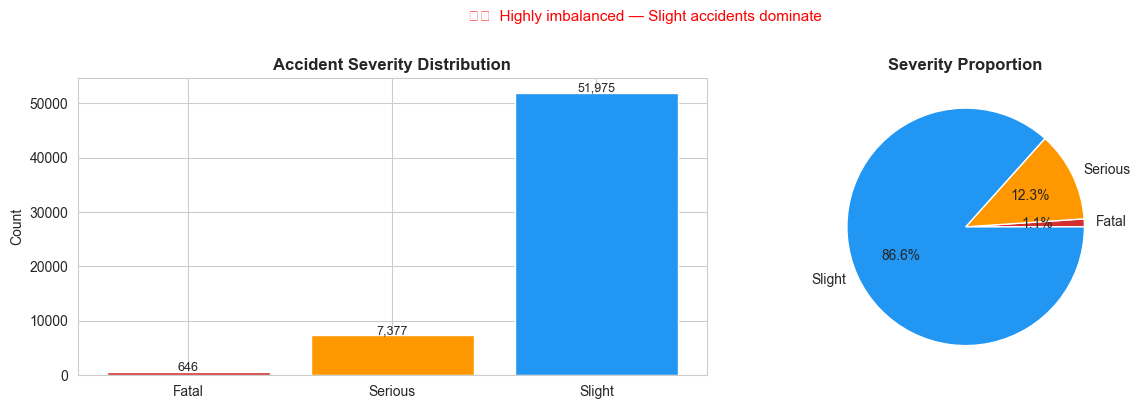

In [8]:
# Severity class distribution
sev_counts = df['Accident_Severity'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar([SEV_LABELS[k] for k in sev_counts.index], sev_counts.values,
            color=[SEV_COLORS[k] for k in sev_counts.index])
axes[0].set_title('Accident Severity Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sev_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(sev_counts.values,
            labels=[SEV_LABELS[k] for k in sev_counts.index],
            autopct='%1.1f%%',
            colors=[SEV_COLORS[k] for k in sev_counts.index])
axes[1].set_title('Severity Proportion', fontweight='bold')

plt.suptitle('⚠️  Highly imbalanced — Slight accidents dominate',
             y=1.01, color='red', fontsize=11)
plt.tight_layout()
plt.show()

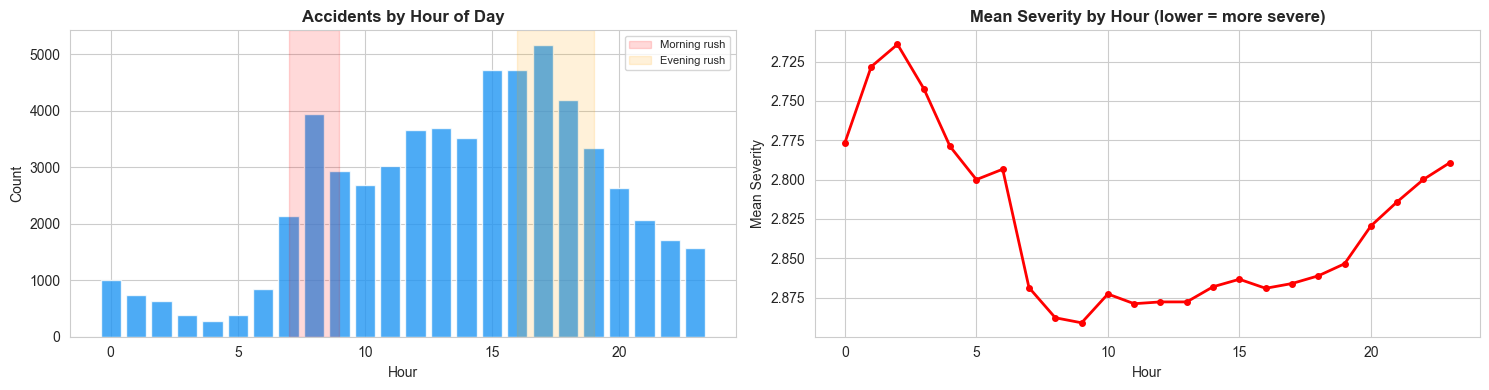

In [ ]:
#Time-of-day patterns
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Accident count by hour
hour_count = df.groupby('Hour').size()
axes[0].bar(hour_count.index, hour_count.values, color='#2196F3', alpha=0.8)
axes[0].set_title('Accidents by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Count')
axes[0].axvspan(7, 9,   alpha=0.15, color='red', label='Morning rush')
axes[0].axvspan(16, 19, alpha=0.15, color='orange', label='Evening rush')
axes[0].legend(fontsize=8)

# Mean severity by hour (lower = more severe)
hour_sev = df.groupby('Hour')['Accident_Severity'].mean()
axes[1].plot(hour_sev.index, hour_sev.values, color='red', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Mean Severity by Hour', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Mean Severity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

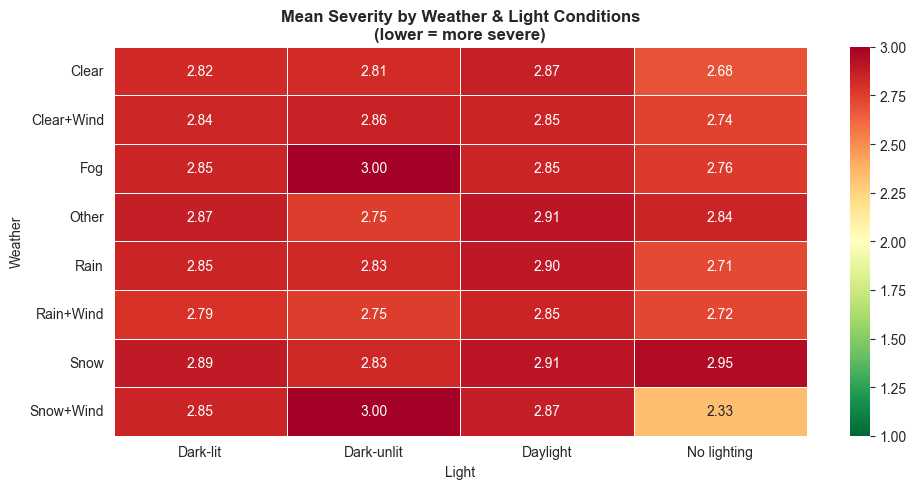

In [10]:
# Weather & Light conditions heatmap 
weather_map = {1:'Clear', 2:'Rain', 3:'Snow', 4:'Clear+Wind',
               5:'Rain+Wind', 6:'Snow+Wind', 7:'Fog', 8:'Other'}
light_map   = {1:'Daylight', 4:'Dark-lit', 5:'Dark-unlit', 6:'No lighting'}

df_eda = df[df['Weather_Conditions'].isin(weather_map.keys()) &
            df['Light_Conditions'].isin(light_map.keys())].copy()
df_eda['Weather'] = df_eda['Weather_Conditions'].map(weather_map)
df_eda['Light']   = df_eda['Light_Conditions'].map(light_map)

pivot = df_eda.pivot_table(
    values='Accident_Severity', index='Weather', columns='Light', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=1, vmax=3)
ax.set_title('Mean Severity by Weather & Light Conditions\n(lower = more severe)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

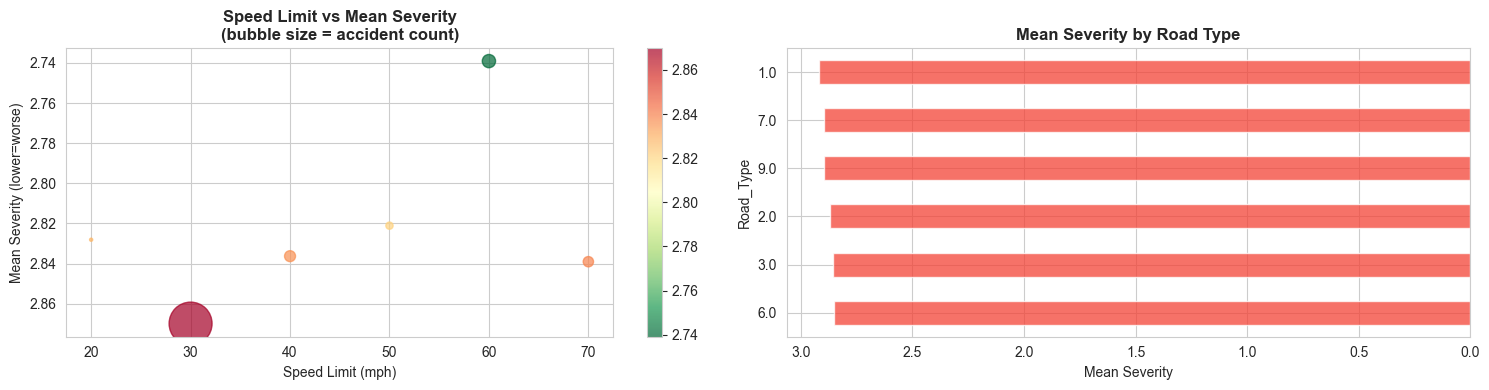

In [11]:
#Road & speed analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

speed_sev = df.groupby('Speed_limit')['Accident_Severity'].agg(['mean', 'count']).reset_index()
speed_sev = speed_sev[speed_sev['count'] > 100]

sc = axes[0].scatter(speed_sev['Speed_limit'], speed_sev['mean'],
                     s=speed_sev['count'] / 50, alpha=0.7,
                     c=speed_sev['mean'], cmap='RdYlGn_r')
axes[0].set_title('Speed Limit vs Mean Severity\n(bubble size = accident count)',
                  fontweight='bold')
axes[0].set_xlabel('Speed Limit (mph)'); axes[0].set_ylabel('Mean Severity (lower=worse)')
axes[0].invert_yaxis()
plt.colorbar(sc, ax=axes[0])

road_sev = df.groupby('Road_Type')['Accident_Severity'].mean().sort_values()
road_sev.plot(kind='barh', ax=axes[1], color='#F44336', alpha=0.75)
axes[1].set_title('Mean Severity by Road Type', fontweight='bold')
axes[1].set_xlabel('Mean Severity'); axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

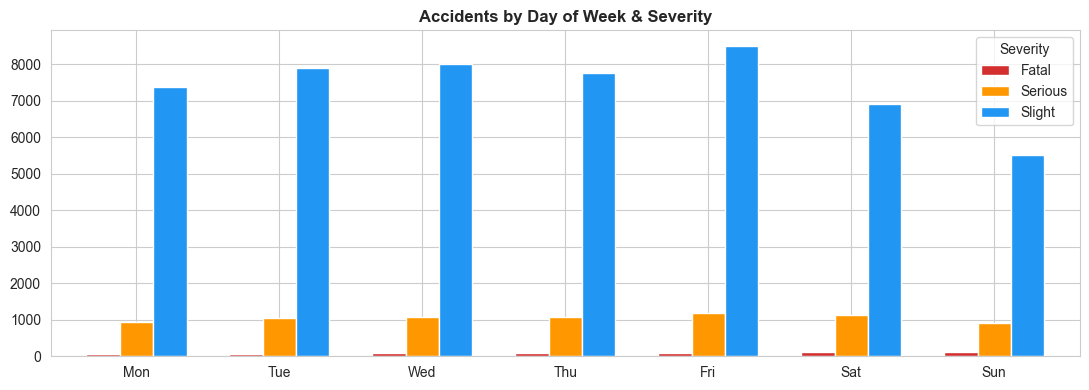

In [13]:
# Day of week pattern
day_map = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
df['Day_Name'] = df['Day_of_Week'].map(day_map)

day_pivot = df.groupby(['Day_Name', 'Accident_Severity']).size().unstack(fill_value=0)
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_pivot = day_pivot.reindex(day_order)
day_pivot.columns = [SEV_LABELS[c] for c in day_pivot.columns]

fig, ax = plt.subplots(figsize=(11, 4))
day_pivot.plot(kind='bar', ax=ax, color=[SEV_COLORS[k] for k in SEV_COLORS],
               edgecolor='white', width=0.7)
ax.set_title('Accidents by Day of Week & Severity', fontweight='bold', fontsize=12)
ax.set_xlabel(''); ax.set_xticklabels(day_order, rotation=0)
ax.legend(title='Severity')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering
Six new features derived from domain knowledge about accident risk.

In [14]:
# Extract date features
df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Month']       = df['Date_parsed'].dt.month

# New engineered features 
# Rush hour: 7-9 AM or 16-19 PM on weekdays
df['Is_Rush_Hour'] = (
    ((df['Hour'].between(7, 9)) | (df['Hour'].between(16, 19))) &
    (df['Day_of_Week'].between(2, 6))          # Mon–Fri
).astype(int)

# Weekend flag
df['Is_Weekend'] = df['Day_of_Week'].isin([1, 7]).astype(int)

# Night driving: 22:00 – 05:59
df['Is_Night'] = (df['Hour'].between(22, 23) | df['Hour'].between(0, 5)).astype(int)

# Season: 1=Winter, 2=Spring, 3=Summer, 4=Autumn
def get_season(m):
    if m in [12, 1, 2]: return 1
    elif m in [3, 4, 5]: return 2
    elif m in [6, 7, 8]: return 3
    else: return 4

df['Season'] = df['Month'].apply(get_season)

# Road risk score: combine speed limit + road type + junction
# Higher = riskier conditions
df['Speed_norm']    = (df['Speed_limit'].clip(20, 70) - 20) / 50
df['Road_Risk_Score'] = df['Speed_norm'] + \
                        df['Road_Surface_Conditions'].clip(0, 5) / 5 + \
                        df['Weather_Conditions'].clip(0, 9) / 9
df['Road_Risk_Score'] = df['Road_Risk_Score'].clip(0, 3) / 3  # normalise to [0,1]

# High-casualty flag
df['High_Casualty'] = (df['num_casualties'] >= 3).astype(int)

print('New features added: Is_Rush_Hour, Is_Weekend, Is_Night, Season, Road_Risk_Score, High_Casualty')
print(df[['Is_Rush_Hour','Is_Weekend','Is_Night','Season','Road_Risk_Score','High_Casualty']].describe())

New features added: Is_Rush_Hour, Is_Weekend, Is_Night, Season, Road_Risk_Score, High_Casualty
       Is_Rush_Hour    Is_Weekend      Is_Night        Season  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   2.072336e-02  1.401140e-02  6.392485e-03  3.915640e+00   
std    1.424567e-01  1.175376e-01  7.969710e-02  4.340686e-01   
min    0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00  4.000000e+00   
50%    0.000000e+00  0.000000e+00  0.000000e+00  4.000000e+00   
75%    0.000000e+00  0.000000e+00  0.000000e+00  4.000000e+00   
max    1.000000e+00  1.000000e+00  1.000000e+00  4.000000e+00   

       Road_Risk_Score  High_Casualty  
count     59998.000000      1048575.0  
mean          0.238346            0.0  
std           0.107427            0.0  
min           0.103704            0.0  
25%           0.170370            0.0  
50%           0.170370            0.0  
75%           0.274074            0.0  

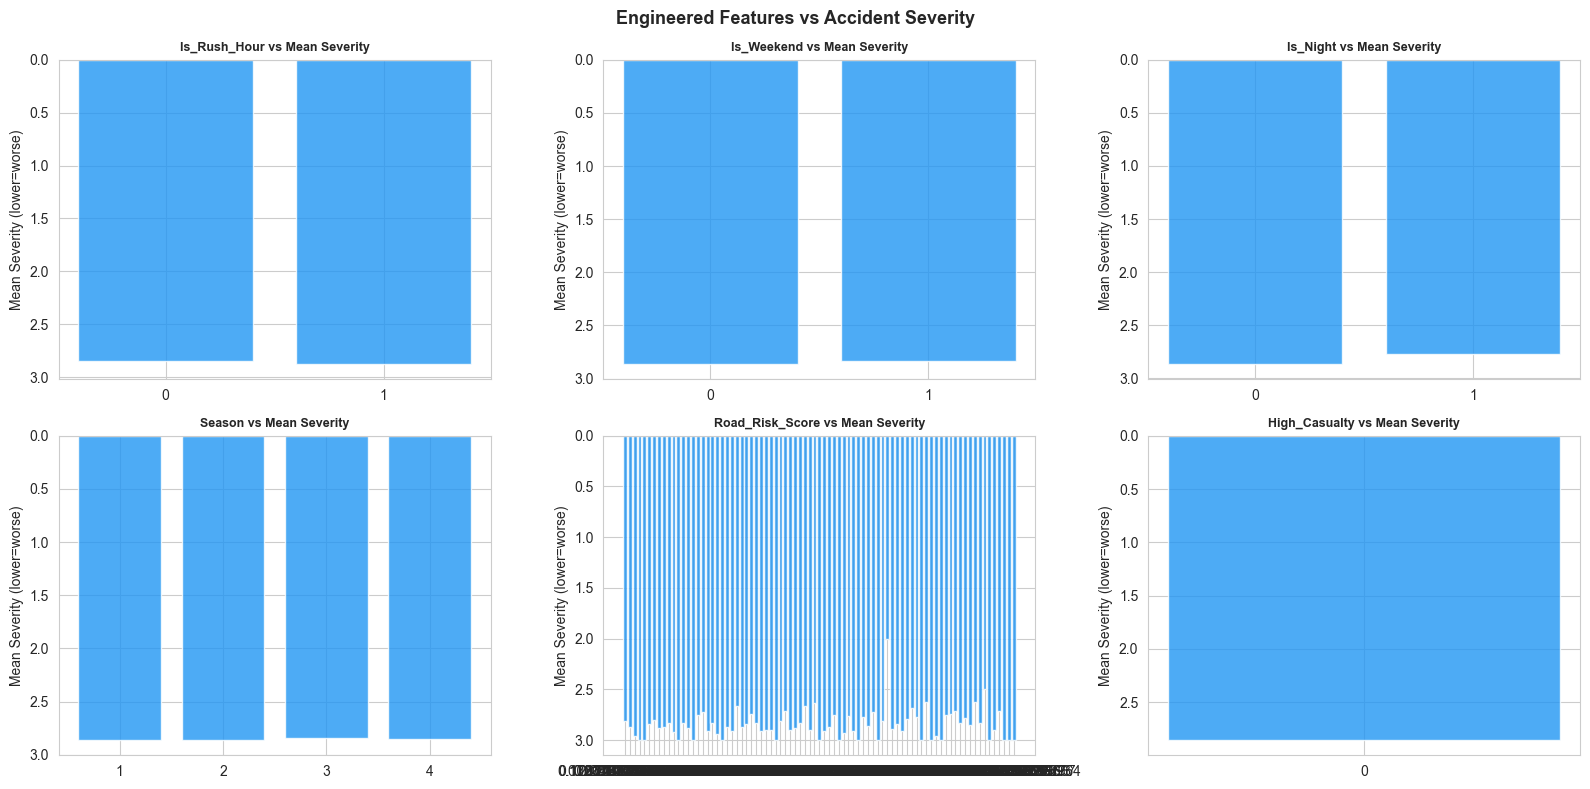

In [15]:
# Visualise new features vs severity
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

new_feats = ['Is_Rush_Hour', 'Is_Weekend', 'Is_Night',
             'Season', 'Road_Risk_Score', 'High_Casualty']

for ax, feat in zip(axes.flatten(), new_feats):
    feat_sev = df.groupby(feat)['Accident_Severity'].mean()
    ax.bar(feat_sev.index.astype(str), feat_sev.values,
           color='#2196F3', alpha=0.8)
    ax.set_title(f'{feat} vs Mean Severity', fontweight='bold', fontsize=9)
    ax.set_ylabel('Mean Severity (lower=worse)')
    ax.invert_yaxis()

plt.suptitle('Engineered Features vs Accident Severity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Preprocessing

In [17]:

drop_cols = [
    'Accident_Index', 'Number_of_Vehicles', 'Number_of_Casualties',
    'Time', 'Date', 'Date_parsed', 'Day_Name',
    'Pedestrian_Road_Maintenance_Worker', 'Local_Authority_(District)',
    'Police_Force', 'Casualty_Severity', 'Vehicle_Reference_x',
    'Vehicle_Reference_y', 'Casualty_Reference',
    'LSOA_of_Accident_Location', '1st_Road_Number', '2nd_Road_Number',
    'Towing_and_Articulation', 'Vehicle_Location-Restricted_Lane',
    'Junction_Location', 'Skidding_and_Overturning',
    'Hit_Object_in_Carriageway', 'Vehicle_Leaving_Carriageway',
    'Hit_Object_off_Carriageway', '1st_Point_of_Impact',
    'Was_Vehicle_Left_Hand_Drive?', 'Journey_Purpose_of_Driver',
    'Driver_IMD_Decile', 'Driver_Home_Area_Type', 'Casualty_Home_Area_Type',
    'Age_Band_of_Driver', 'Age_Band_of_Casualty',
    'Car_Passenger', 'Bus_or_Coach_Passenger',
    'Pedestrian_Location', 'Pedestrian_Movement',
    'Local_Authority_(Highway)', '1st_Road_Class', '2nd_Road_Class',
    'Special_Conditions_at_Site', 'Carriageway_Hazards',
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'Propulsion_Code', 'Pedestrian_Crossing-Human_Control',
    'Pedestrian_Crossing-Physical_Facilities',
    'Engine_Capacity_(CC)', 'Speed_norm'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# sentinel values 
df.replace(-1, np.nan, inplace=True)

df = df.dropna(subset=['Accident_Severity'])

num_cols = df.select_dtypes(include=['float64','int64']).columns.drop('Accident_Severity')
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Clean dataset shape: {df.shape}')
print(f'Null values remaining: {df.isnull().sum().sum()}')
print(f'Features: {df.shape[1] - 1}')

Clean dataset shape: (59998, 31)
Null values remaining: 0
Features: 30


---
## 6. Train / Test Split + SMOTE

In [18]:
X = df.drop('Accident_Severity', axis=1)
y = df['Accident_Severity'] - 1   # 0=Fatal, 1=Serious, 2=Slight

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'Train (after SMOTE): {X_train_sm.shape}')
print(f'Test:                {X_test.shape}')
print('\nClass balance after SMOTE:')
print(pd.Series(y_train_sm).value_counts().sort_index())

Train (after SMOTE): (124740, 30)
Test:                (12000, 30)

Class balance after SMOTE:
Accident_Severity
0.0    41580
1.0    41580
2.0    41580
Name: count, dtype: int64


---
## 7. Training

In [2]:

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
}

results   = {}
trained   = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')

    # Use scaled data for Logistic Regression
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train_sm
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train_sm)
    y_pred      = model.predict(Xte)
    y_pred_prob = model.predict_proba(Xte)

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC one-vs-rest
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_test, classes=[0,1,2])
    auc   = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='macro')

    results[name] = {
        'Accuracy': round(acc, 4),
        'Balanced Acc': round(bacc, 4),
        'Macro F1': round(f1_m, 4),
        'Weighted F1': round(f1_w, 4),
        'ROC AUC': round(auc, 4),
        'y_pred': y_pred
    }
    trained[name] = model
    print(f'  Acc={acc:.4f}  MacroF1={f1_m:.4f}  AUC={auc:.4f}')

NameError: name 'LogisticRegression' is not defined

---
## 8. Model Comparison

In [ ]:
# --- 8.1 Summary table ---
summary_df = pd.DataFrame(
    {k: {m: v for m, v in vals.items() if m != 'y_pred'}
     for k, vals in results.items()}
).T

print('Model Comparison:')
display(summary_df.style.highlight_max(color='lightgreen').format('{:.4f}'))

In [ ]:
# Grouped bar chart
metrics = ['Accuracy', 'Balanced Acc', 'Macro F1', 'ROC AUC']
x = np.arange(len(metrics))
w = 0.20

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(results.keys(), MODEL_COLORS)):
    vals = [summary_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices
def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fatal','Serious','Slight'],
                yticklabels=['Fatal','Serious','Slight'],
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, vals) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    plot_cm(cm, name, ax)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Classification reports
for name, vals in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(classification_report(
        y_test, vals['y_pred'],
        target_names=['Fatal','Serious','Slight']
    ))

---
## 9. Feature Importance & Interpretability

In [ ]:
# Feature importance for tree-based model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ['Random Forest', 'XGBoost', 'LightGBM']):
    model = trained[name]
    fi = pd.Series(model.feature_importances_, index=X.columns)
    fi.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
    ax.set_title(f'{name} — Top 15 Features', fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
# --- 9.2 SHAP values for best model ---
# Identify best model by Macro F1
best_name  = summary_df['Macro F1'].astype(float).idxmax()
best_model = trained[best_name]
print(f'Best model: {best_name}')

try:
    import shap

    # Use a small sample for speed
    sample_idx = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
    X_sample   = X_test.iloc[sample_idx] if hasattr(X_test, 'iloc') else X_test[sample_idx]

    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(X_sample)

    # Summary plot — class 0 (Fatal, most critical)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_vals[0] if isinstance(shap_vals, list) else shap_vals,
        X_sample, plot_type='bar', show=False, max_display=15
    )
    plt.title(f'SHAP Feature Importance — {best_name} (Fatal class)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Showing Random Forest importances instead.')
    fi = pd.Series(best_model.feature_importances_, index=X.columns)
    fi.nlargest(15).sort_values().plot(kind='barh', figsize=(9,5), color='#FF9800')
    plt.title(f'Feature Importance — {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

NameError: name 'summary_df' is not defined

---
## 10. Save Best Model

In [ ]:
with open('best_accident_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f'✅ Saved: best_accident_model.pkl  ({best_name})')
print( '✅ Saved: scaler.pkl')
print( '✅ Saved: feature_columns.pkl')

---
## 11. Live Prediction Function
Enter accident conditions and get a severity prediction with a risk score.

In [ ]:
FEATURE_COLUMNS = list(X.columns)

def predict_accident(
    hour=8,
    speed_limit=60,
    road_type=6,              # 6=single carriageway
    weather_conditions=1,     # 1=fine
    light_conditions=1,       # 1=daylight
    road_surface=1,           # 1=dry
    urban_rural=1,            # 1=urban
    num_vehicles=2,
    num_casualties=1,
    age_of_driver=35.0,
    age_of_vehicle=5.0,
    day_of_week=2,            # Monday
    junction_detail=0,
    model=None,
    verbose=True
):
    """
    Predict accident severity from conditions.
    Returns: dict with severity label, probability, and risk score.
    """
    if model is None:
        model = best_model

    # Compute derived features
    is_rush  = int((hour in range(7,10) or hour in range(16,20)) and day_of_week in range(2,7))
    is_wkend = int(day_of_week in [1, 7])
    is_night = int(hour >= 22 or hour <= 5)
    month    = 6   # default June
    season   = get_season(month)
    speed_n  = (min(max(speed_limit, 20), 70) - 20) / 50
    rr_score = (speed_n + road_surface / 5 + weather_conditions / 9)
    rr_score = min(rr_score / 3, 1.0)
    high_cas = int(num_casualties >= 3)

    # Build input row with all feature defaults
    row = {col: 0 for col in FEATURE_COLUMNS}
    row.update({
        'Hour': hour, 'Speed_limit': speed_limit,
        'Road_Type': road_type, 'Weather_Conditions': weather_conditions,
        'Light_Conditions': light_conditions, 'Road_Surface_Conditions': road_surface,
        'Urban_or_Rural_Area': urban_rural, 'num_vehicles': num_vehicles,
        'num_casualties': num_casualties, 'Age_of_Driver': age_of_driver,
        'Age_of_Vehicle': age_of_vehicle, 'Day_of_Week': day_of_week,
        'Junction_Detail': junction_detail, 'Month': month,
        'Is_Rush_Hour': is_rush, 'Is_Weekend': is_wkend, 'Is_Night': is_night,
        'Season': season, 'Road_Risk_Score': rr_score, 'High_Casualty': high_cas
    })

    X_in = pd.DataFrame([row])[FEATURE_COLUMNS].values.astype(float)

    probs      = model.predict_proba(X_in)[0]
    pred_class = int(np.argmax(probs))
    severity   = {0: 'Fatal', 1: 'Serious', 2: 'Slight'}[pred_class]
    color      = {0: 'red', 1: 'orange', 2: 'green'}[pred_class]

    if verbose:
        print(f'\n{"─"*45}')
        print(f'  🚦 Predicted Severity: {severity}')
        print(f'  📊 Probabilities:')
        for label, p in zip(['Fatal','Serious','Slight'], probs):
            bar = '█' * int(p * 30)
            print(f'     {label:8s}: {p*100:5.1f}%  {bar}')
        print(f'  ⚠️  Road Risk Score: {rr_score:.2f}')
        print(f'{"─"*45}')

        fig, ax = plt.subplots(figsize=(7, 3))
        bar_cols = ['#d32f2f','#ff9800','#2196F3']
        bars = ax.bar(['Fatal','Serious','Slight'], probs*100, color=bar_cols, alpha=0.85)
        ax.set_ylim(0, 115); ax.set_ylabel('Probability (%)')
        ax.set_title(f'Prediction: {severity}  |  Risk Score: {rr_score:.2f}',
                     fontweight='bold', color=color)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{p*100:.1f}%', ha='center', fontsize=10)
        plt.tight_layout()
        plt.show()

    return {'severity': severity, 'probabilities': dict(zip(['Fatal','Serious','Slight'], probs.tolist())),
            'risk_score': round(rr_score, 3)}


print('✅ predict_accident() ready.\n')
print('Example scenarios:')

# Scenario 1: Risky — night, fast, wet, dark
print('\n🌧️  Scenario: Night motorway, wet road, 70mph')
predict_accident(hour=2, speed_limit=70, weather_conditions=2,
                 light_conditions=5, road_surface=2, urban_rural=2)

# Scenario 2: Safe — daylight, slow, dry, urban
print('\n☀️  Scenario: Daytime urban road, 20mph, dry')
predict_accident(hour=10, speed_limit=20, weather_conditions=1,
                 light_conditions=1, road_surface=1, urban_rural=1)